# 02 — Data Cleaning and Exploratory Analysis

**Phase 3** of the project plan, built up across several steps:

1. Cleaning policy — decided and documented in `reports/cleaning_policy.md` (no code here).
2. Cleaning implementation — `src/auto_pricing/features.py` + `scripts/prepare_data.py`, producing `data/processed/`.
3. **This section:** univariate exploratory analysis — exposure and claim-count distributions, and the portfolio-level annual claim frequency.
4. Frequency by rating factor (added in a later step).
5. Severity distribution and large-loss concentration (added in a later step).
6. Pure premium distribution and wrap-up (added in a later step).

This notebook loads the **cleaned** tables (`load_frequency_clean`, `load_severity_clean`), not the raw ones — by this point, Exposure is already capped at 1.0, ClaimNb at 4, and orphaned claims already excluded, per the documented policy.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from auto_pricing.data import load_frequency_clean, load_severity_clean
from auto_pricing.eda import exposure_weighted_frequency, naive_mean_frequency, zero_claim_share

FIGURES_DIR = Path("..") / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

freq = load_frequency_clean()
sev = load_severity_clean()

print("frequency (cleaned):", freq.shape)
print("severity (cleaned): ", sev.shape)

frequency (cleaned): (678013, 12)
severity (cleaned):  (26444, 2)


## 1. Exposure distribution

Exposure is the fraction of a policy-year each policy was observed. It matters here for a specific reason: a lot of policies have short exposure, and short-exposure policies are exactly what makes the naive frequency calculation in Section 3 go wrong.

In [2]:
freq["Exposure"].describe()

count    678013.000000
mean          0.528545
std           0.364081
min           0.002732
25%           0.180000
50%           0.490000
75%           0.990000
max           1.000000
Name: Exposure, dtype: float64

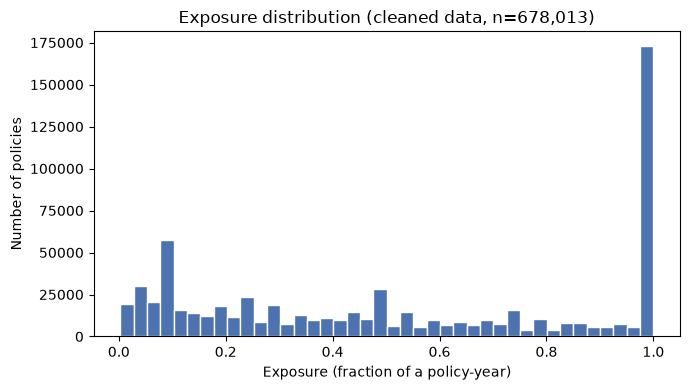

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(freq["Exposure"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Exposure (fraction of a policy-year)")
ax.set_ylabel("Number of policies")
ax.set_title("Exposure distribution (cleaned data, n=678,013)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exposure_distribution.png", dpi=150)
plt.show()

The distribution is far from uniform: there's a spike near `Exposure = 1.0` (full-year policies, now including the 1,224 that were clipped down from above 1.0) and a long, fairly flat spread across shorter exposures. In other words, a meaningful share of the portfolio was only observed for a fraction of the year — exactly the situation Exposure exists to account for.

## 2. Claim count distribution and the zero-claim share

In [4]:
claim_counts = freq["ClaimNb"].value_counts().sort_index()
print(claim_counts)
print()
print(f"zero-claim share: {zero_claim_share(freq):.4%}")

ClaimNb
0    643953
1     32178
2      1784
3        82
4        16
Name: count, dtype: int64

zero-claim share: 94.9765%


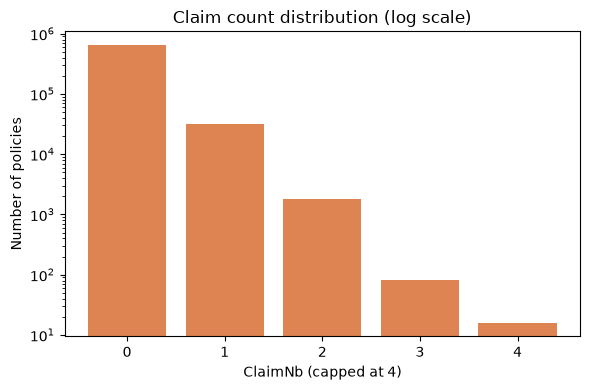

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(claim_counts.index.astype(str), claim_counts.values, color="#DD8452")
ax.set_xlabel("ClaimNb (capped at 4)")
ax.set_ylabel("Number of policies")
ax.set_yscale("log")
ax.set_title("Claim count distribution (log scale)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "claim_count_distribution.png", dpi=150)
plt.show()

**~95% of policies have zero claims.** This is the central challenge the whole modelling approach is built around: with claims this sparse, an ordinary regression on raw claim counts would be dominated by noise. It's also why the frequency model is evaluated on exposure-weighted deviance rather than plain accuracy — a model that predicts "zero claims for everyone" would already be right 95% of the time, and that is not a useful pricing model. (The log scale on the y-axis above is there so the 16 policies with `ClaimNb=4` remain visible at all next to the 643,953 with `ClaimNb=0`.)

## 3. Portfolio-level annual claim frequency — correct vs. naive

This is the calculation the project plan is explicit about getting right. The correct portfolio-level annual frequency is

$$\text{frequency} = \frac{\sum_i \text{ClaimNb}_i}{\sum_i \text{Exposure}_i}$$

**not** the plain average of each policy's own `ClaimNb / Exposure`. The two are computed side by side below on the real, cleaned data.

In [6]:
correct = exposure_weighted_frequency(freq)
naive = naive_mean_frequency(freq)

print(f"correct (exposure-weighted): {correct:.5f}  -> {correct*100:.2f} claims per 100 policy-years")
print(f"naive (mean of per-policy rates): {naive:.5f}  -> {naive*100:.2f} claims per 100 policy-years")
print(f"naive method overstates the true rate by {naive/correct:.1f}x")

correct (exposure-weighted): 0.10061  -> 10.06 claims per 100 policy-years
naive (mean of per-policy rates): 0.26350  -> 26.35 claims per 100 policy-years
naive method overstates the true rate by 2.6x


The naive method overstates the portfolio's true claim frequency by roughly **2.6×**. That is not a rounding difference — it would mean pricing every policy in the portfolio as if it were substantially riskier than it actually is. The next cell shows exactly why: a small number of policies with very little exposure but at least one claim produce absurd implied annual rates, and an unweighted average lets each of those count as much as any full-year policy.

In [7]:
tiny_exposure_claims = freq[(freq["Exposure"] < 0.01) & (freq["ClaimNb"] > 0)]
print(f"policies with Exposure < 0.01 years (~3.6 days) AND at least one claim: {len(tiny_exposure_claims)}")

example = tiny_exposure_claims.assign(implied_annual_rate=lambda d: d["ClaimNb"] / d["Exposure"])
example[["IDpol", "Exposure", "ClaimNb", "implied_annual_rate"]].sort_values(
    "implied_annual_rate", ascending=False
).head(5)

policies with Exposure < 0.01 years (~3.6 days) AND at least one claim: 152


,IDpol,Exposure,ClaimNb,implied_annual_rate
3360,7045,0.002732,2,732.0
4554,10019,0.002732,2,732.0
2838,5896,0.002732,2,732.0
716,1489,0.002732,1,366.0
1451,3003,0.002732,1,366.0


A policy exposed for about a day with two claims implies **732 claims per year** if you take its own rate at face value — obviously not a real annual claim rate, just a very small amount of exposure dividing a very small claim count. 152 such policies exist in the cleaned data, and averaging their per-policy rates alongside hundreds of thousands of full-year, zero-claim policies is what inflates the naive figure to 2.6× the truth.

The exposure-weighted formula avoids this because it never treats a claim in isolation from how much exposure produced it: it sums claims and sums exposure *separately*, across the whole group, before dividing. A tiny-exposure policy still contributes its one claim to the numerator, but only its tiny exposure to the denominator — it cannot dominate the result the way its own inflated per-policy rate would.

## 4. Summary

- Exposure is concentrated near 1.0 but spread widely below it — a large share of the portfolio has partial-year exposure.
- ~95% of policies have zero claims; frequency modelling has to work with genuinely sparse data.
- The portfolio's true annual claim frequency is **~10.06 claims per 100 policy-years** (exposure-weighted). The naive unweighted average would report **~26.35 per 100** — 2.6× too high — because it lets a small number of very-short-exposure policies with a claim dominate the result.

`exposure_weighted_frequency()` in `src/auto_pricing/eda.py` also accepts a `by=` argument for exactly this calculation at the segment level (e.g. by `Region` or `DrivAge` bucket), which is what the next step of this notebook uses.

## 5. Frequency by rating factor

For each factor below, `exposure_weighted_frequency(freq, by=...)` (Step 3) is computed per category and shown *together with* the exposure backing each category — a rate estimated from a handful of policy-years is flagged visually, not reported as if it were just as solid as one backed by tens of thousands of policy-years.

Continuous factors (`DrivAge`, `BonusMalus`, `VehAge`) are grouped into actuarially-motivated bands with `bin_numeric` before aggregating. `Density` is grouped into equal-*exposure* quantile bands instead (`pd.qcut`), since its raw distribution is heavily right-skewed and fixed-width bands would leave some bands almost empty.

In [8]:
from auto_pricing.eda import bin_numeric, plot_segment_frequency

freq["DrivAgeBand"] = bin_numeric(
    freq["DrivAge"], bins=[18, 23, 30, 40, 50, 60, 70, 101],
    labels=["18-22", "23-29", "30-39", "40-49", "50-59", "60-69", "70+"],
)
freq["BonusMalusBand"] = bin_numeric(
    freq["BonusMalus"], bins=[50, 51, 60, 80, 100, 130, 231],
    labels=["50 (best)", "51-59", "60-79", "80-99", "100-129", "130+"],
)
freq["VehAgeBand"] = bin_numeric(
    freq["VehAge"], bins=[0, 1, 3, 6, 10, 15, 20, 101],
    labels=["0", "1-2", "3-5", "6-9", "10-14", "15-19", "20+"],
)
freq["DensityBand"] = pd.qcut(
    freq["Density"], q=5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"]
)

### 5.1 Driver factors: `DrivAge`, `BonusMalus`

In [9]:
drivage_table = exposure_weighted_frequency(freq, by="DrivAgeBand")
drivage_table

,DrivAgeBand,n_policies,claim_nb,exposure,frequency
0,18-22,16544,1426,6628.157333,0.215143
1,23-29,72461,3837,31636.384331,0.121284
2,30-39,168564,7350,82320.268465,0.089285
3,40-49,165702,9041,87645.366054,0.103154
4,50-59,142600,7778,79880.858453,0.097370
5,60-69,67812,3714,40077.471786,0.092671
6,70+,44330,2910,30171.599041,0.096448


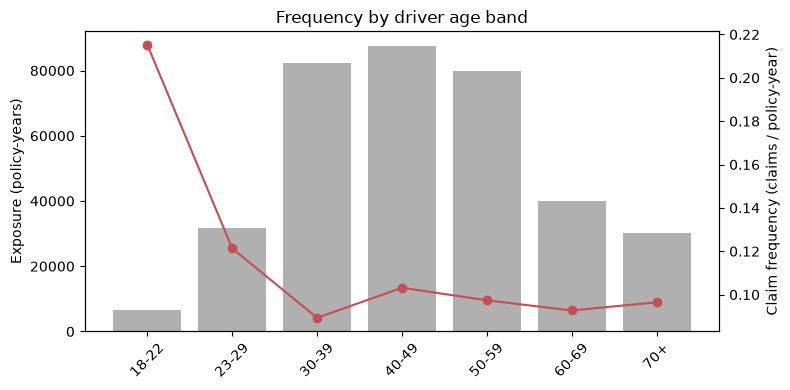

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_segment_frequency(drivage_table, "DrivAgeBand", ax=ax, title="Frequency by driver age band")
fig.savefig(FIGURES_DIR / "frequency_by_drivage.png", dpi=150)
plt.show()

Drivers aged 18-22 have a frequency of **0.215** claims/policy-year — roughly **2.7x** the 30-39 band (0.089), which is the lowest of any age group. The rate falls sharply through the 20s and then stays fairly flat (0.09-0.10) from age 30 onward, with no further strong trend into old age. This is a well-powered finding (16,544 policies / 6,628 policy-years in the 18-22 band alone) — the classic young-driver risk pattern, and clearly non-linear: a single linear `DrivAge` coefficient would badly under-fit the youngest band while over-fitting the flat middle.

In [11]:
bonusmalus_table = exposure_weighted_frequency(freq, by="BonusMalusBand")
bonusmalus_table

,BonusMalusBand,n_policies,claim_nb,exposure,frequency
0,50 (best),384156,18010,225152.650903,0.079990
1,51-59,77083,3798,39809.632987,0.095404
2,60-79,118032,6920,53777.097486,0.128679
3,80-99,71418,4265,29809.491727,0.143075
4,100-129,26539,2901,9447.269451,0.307073
5,130+,785,162,363.962909,0.445100


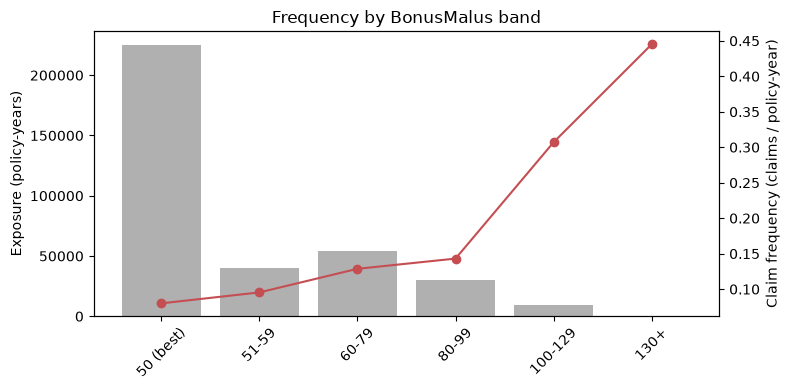

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_segment_frequency(bonusmalus_table, "BonusMalusBand", ax=ax, title="Frequency by BonusMalus band")
fig.savefig(FIGURES_DIR / "frequency_by_bonusmalus.png", dpi=150)
plt.show()

`BonusMalus` is the strongest and cleanest relationship found in this notebook: frequency rises **monotonically** from 0.080 at the best score (50) to 0.445 at 130+ — a 5.6x range, exactly what you'd expect from a field that directly encodes prior claims history. **Credibility flag:** the top band (130+) is backed by only 785 policies / 364 policy-years, versus 384,156 policies / 225,153 policy-years at the best score. The *direction* of the trend is well supported (every band in between confirms it), but the *exact* frequency for 130+ should be treated as a less precise estimate than the others.

### 5.2 Vehicle factors: `VehAge`, `VehPower`, `VehBrand`, `VehGas`

In [13]:
vehage_table = exposure_weighted_frequency(freq, by="VehAgeBand")
vehage_table

,VehAgeBand,n_policies,claim_nb,exposure,frequency
0,0,57739,5205,16696.328729,0.311745
1,1-2,130408,5699,62441.616619,0.091269
2,3-5,132490,6743,72021.113776,0.093625
3,6-9,133199,7765,78031.752595,0.099511
4,10-14,148835,7726,86058.993774,0.089776
5,15-19,63655,2517,35966.514321,0.069982
6,20+,11687,401,7143.785648,0.056133


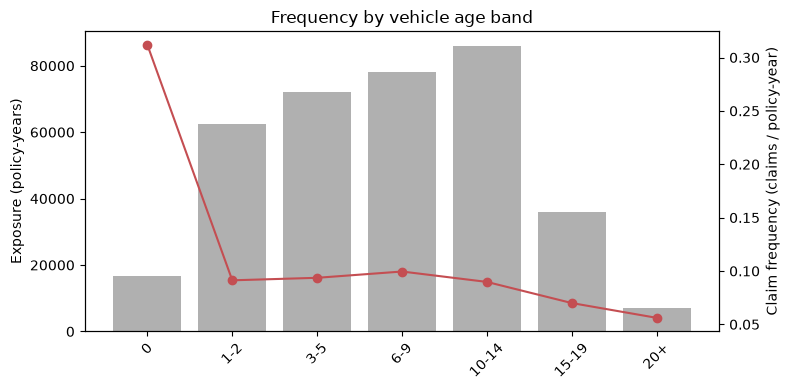

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_segment_frequency(vehage_table, "VehAgeBand", ax=ax, title="Frequency by vehicle age band")
fig.savefig(FIGURES_DIR / "frequency_by_vehage.png", dpi=150)
plt.show()

Unexpected pattern: brand-new vehicles (`VehAge=0`) have the **highest** frequency of any band, 0.312 — even higher than the youngest driver band above — then it drops sharply to 0.091 for 1-2 year old vehicles, and declines gently after that down to 0.056 for 20+ years. This is not small-sample noise (57,739 policies / 16,696 policy-years back the `VehAge=0` figure). It is also not monotonic, which `DrivAge` and `BonusMalus` roughly are — a plain linear `VehAge` term would fit this badly. This needs a documented, deliberate choice in Phase 4 (a spline, or keeping this band structure), not a linear coefficient.

In [15]:
vehpower_table = exposure_weighted_frequency(freq, by="VehPower")
vehpower_table

,VehPower,n_policies,claim_nb,exposure,frequency
0,4,115349,5661,60055.327304,0.094263
1,5,124821,7271,68148.128821,0.106694
2,6,148976,8381,82497.590172,0.101591
3,7,145401,7626,77919.746700,0.097870
4,8,46956,1922,22673.966305,0.084767
5,9,30085,1754,15338.643656,0.114352
6,10,31354,1789,15367.090824,0.116418
7,11,18352,897,8491.308452,0.105637
8,12,8214,359,3790.798343,0.094703
9,13,3229,153,1637.035322,0.093462


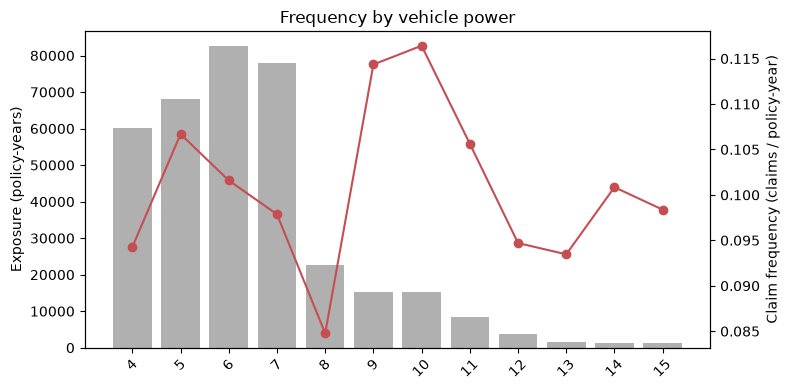

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_segment_frequency(vehpower_table, "VehPower", ax=ax, title="Frequency by vehicle power")
fig.savefig(FIGURES_DIR / "frequency_by_vehpower.png", dpi=150)
plt.show()

`VehPower` shows no strong or clean trend — frequency stays in a fairly narrow 0.085-0.116 range across all 12 power levels, with no obvious monotonic direction. Of the factors examined so far, this looks like the weakest predictor on its own.

In [17]:
vehbrand_table = exposure_weighted_frequency(freq, by="VehBrand").sort_values("frequency")
vehbrand_table

,VehBrand,n_policies,claim_nb,exposure,frequency
5,B14,4047,166,2270.507743,0.073111
6,B2,159861,8552,94823.757101,0.090188
1,B10,17707,858,9489.844123,0.090412
0,B1,162736,8639,95314.989578,0.090636
10,B6,28548,1462,15677.423599,0.093255
8,B4,25179,1312,13770.056080,0.095279
4,B13,12178,649,6768.032216,0.095892
7,B3,53395,2818,28576.436331,0.098613
9,B5,34753,2020,19983.602695,0.101083
2,B11,13585,721,6883.077279,0.104750


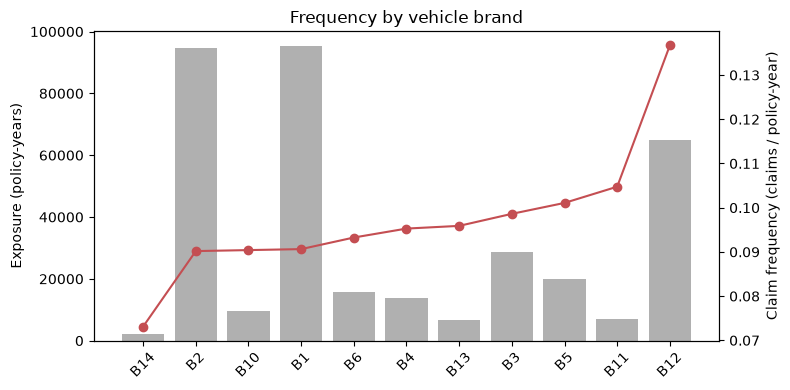

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_segment_frequency(vehbrand_table, "VehBrand", ax=ax, title="Frequency by vehicle brand")
fig.savefig(FIGURES_DIR / "frequency_by_vehbrand.png", dpi=150)
plt.show()

`VehBrand` frequencies range from 0.073 (`B14`) to 0.137 (`B12`). **Credibility flag:** `B14` has both the lowest frequency *and* the least exposure of any brand (4,047 policies / 2,271 policy-years, versus over 90,000 policy-years for `B1`/`B2`) — its low rate should not yet be read as "B14 vehicles are the safest," since it is also the estimate with the widest uncertainty. `B12`, the highest-frequency brand, is backed by 64,802 policy-years, so that result is much more trustworthy.

In [19]:
vehgas_table = exposure_weighted_frequency(freq, by="VehGas")
vehgas_table

,VehGas,n_policies,claim_nb,exposure,frequency
0,Diesel,332136,16640,170587.553127,0.097545
1,Regular,345877,19416,187772.552336,0.103402


`VehGas` shows only a small difference (Diesel 0.098 vs. Regular 0.103) across two well-powered groups — a minor factor at best, on this univariate view.

### 5.3 Geographic factors: `Area`, `Region`, `Density`

In [20]:
area_table = exposure_weighted_frequency(freq, by="Area")
area_table

,Area,n_policies,claim_nb,exposure,frequency
0,A,103957,5056,61956.827712,0.081605
1,B,75459,3800,43001.823931,0.088368
2,C,191880,9875,104402.523785,0.094586
3,D,151596,8390,77087.801692,0.108837
4,E,137167,7804,63785.694270,0.122347
5,F,17954,1131,8125.434074,0.139193


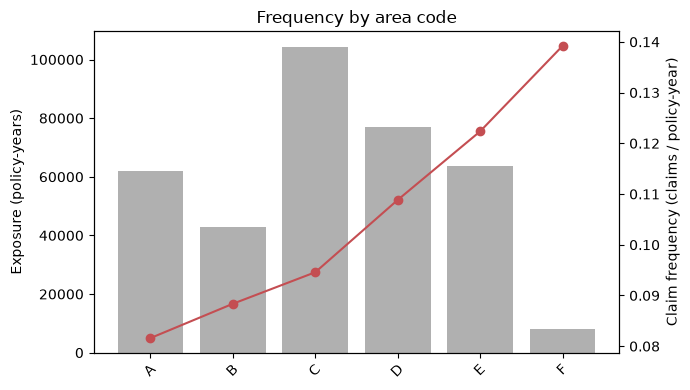

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_segment_frequency(area_table, "Area", ax=ax, title="Frequency by area code")
fig.savefig(FIGURES_DIR / "frequency_by_area.png", dpi=150)
plt.show()

`Area` rises monotonically from A (0.082) to F (0.139), consistent with an urban-density-like gradient, and every band has ample exposure (the smallest, F, still has 8,125 policy-years).

In [22]:
region_table = exposure_weighted_frequency(freq, by="Region").sort_values("frequency")
region_table

,Region,n_policies,claim_nb,exposure,frequency
8,R41,12990,611,8112.487972,0.075316
18,R83,5287,189,2322.274229,0.081386
13,R54,19046,968,11163.008715,0.086715
4,R24,160601,9197,102706.443386,0.089546
11,R52,38751,2010,21930.321165,0.091654
14,R72,31329,1348,14316.166692,0.094159
5,R25,10893,633,6652.651142,0.095150
3,R23,8784,303,3176.882181,0.095377
12,R53,42122,2702,27752.793675,0.097360
15,R73,17141,688,7014.428555,0.098084


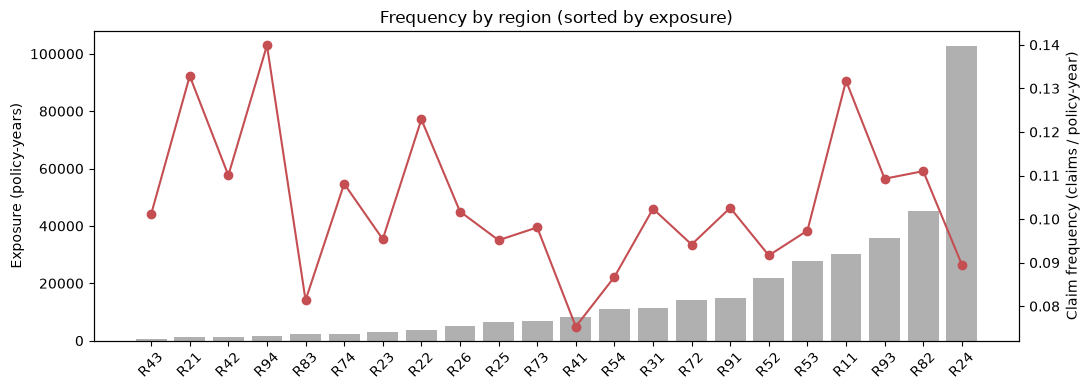

In [23]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_segment_frequency(
    region_table.sort_values("exposure"), "Region", ax=ax, title="Frequency by region (sorted by exposure)"
)
fig.savefig(FIGURES_DIR / "frequency_by_region.png", dpi=150)
plt.show()

`Region` frequencies range from 0.075 (`R41`) to 0.140 (`R94`), a real but moderate spread. **Credibility flag:** exposure varies enormously by region — `R24` alone has 102,706 policy-years, while `R43` has only 564 (1,326 policies) and `R21` only 1,204. `R43`'s frequency (0.101) happens to land near the portfolio average, but with this little data behind it, that could easily be true by chance rather than because `R43` is truly an average-risk region. This is exactly the "credibility of small segments" issue the plan calls out: 22 regions is a lot of categories to fit reliably, and several of them are thinly populated.

In [24]:
density_table = exposure_weighted_frequency(freq, by="DensityBand")
density_table

,DensityBand,n_policies,claim_nb,exposure,frequency
0,Q1 lowest,137340,6746,81391.989565,0.082883
1,Q2,134178,6743,74079.359570,0.091024
2,Q3,135398,7091,72007.451585,0.098476
3,Q4,137845,7817,69456.813925,0.112545
4,Q5 highest,133252,7659,61424.490818,0.124690


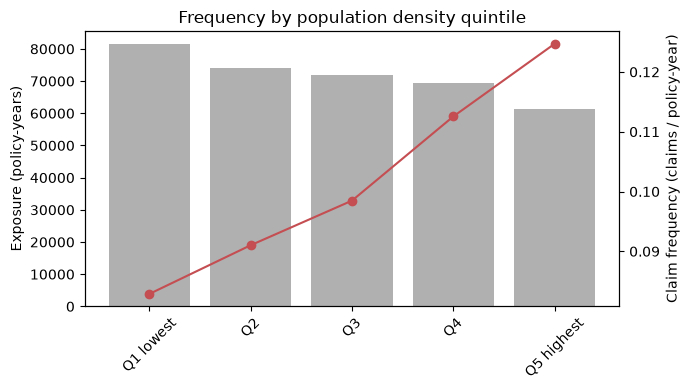

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_segment_frequency(density_table, "DensityBand", ax=ax, title="Frequency by population density quintile")
fig.savefig(FIGURES_DIR / "frequency_by_density.png", dpi=150)
plt.show()

`Density` rises cleanly and monotonically from 0.083 (least dense quintile) to 0.125 (most dense) — by construction, every quintile has almost exactly the same exposure (~135,000 policy-years each), so this trend is well supported throughout, not just at the extremes.

## 6. Segments with limited credibility — a consolidated view

Three specific segments stood out above as having noticeably less exposure than their peers. Listed together here so they aren't lost among nine separate factor sections:

| Factor | Segment | Policy-years | Frequency | Concern |
|---|---|---|---|---|
| BonusMalus | 130+ | 364 | 0.445 | Direction (higher BonusMalus -> higher frequency) is well supported by every other band; this exact magnitude is not |
| Region | R43 | 564 | 0.101 | Smallest region by exposure; its near-average rate could be chance, not a real finding |
| VehBrand | B14 | 2,271 | 0.073 | Lowest exposure of any brand; its low rate should not yet be read as "safest brand" |

None of these are being excluded or capped — the plan is explicit that a model should still be able to price every segment. The point of flagging them here is so that, in Phase 5, credibility-weighting or shrinkage (e.g. a GLM's regularization, or partial pooling toward the portfolio average) is applied deliberately to segments like these, rather than letting a noisy small-sample estimate be trusted as if it were as solid as `BonusMalus=50` or `Region=R24`.

## 7. Summary of Step 4 findings

| Factor | Strength of relationship | Shape |
|---|---|---|
| BonusMalus | **Strong** (0.080 -> 0.445, 5.6x) | Monotonic |
| DrivAge | **Strong** for young drivers (0.215 at 18-22 vs. ~0.09-0.10 elsewhere) | Non-linear: sharp drop, then flat |
| VehAge | **Strong**, unexpected (0.312 at age 0, dropping to 0.056 at 20+) | Non-monotonic: spike then decline |
| Density | Moderate (0.083 -> 0.125) | Monotonic |
| Area | Moderate (0.082 -> 0.139) | Monotonic |
| Region | Moderate (0.075 -> 0.140), several low-exposure segments | Not ordered (categorical) |
| VehBrand | Moderate (0.073 -> 0.137), lowest-exposure brand also lowest frequency | Not ordered (categorical) |
| VehGas | Weak (0.098 vs. 0.103) | Two categories only |
| VehPower | Weak / no clear trend (0.085-0.116) | Roughly flat |

Two things carry directly into later phases:

1. **`DrivAge` and `VehAge` are clearly non-linear.** Phase 4's feature engineering should not    fit either as a single linear coefficient — the banding used here (or splines) needs to    carry through, or the GLM will badly misfit the youngest drivers and the newest vehicles.
2. **`BonusMalus`, `Region`, and `VehBrand` each have at least one segment with materially less    exposure than its peers.** These are exactly the segments Phase 5's credibility-weighting    or regularization needs to handle carefully, rather than trusting their point estimates at    face value.

## 8. Severity distribution and large-loss concentration

Switching from the frequency table to the cleaned severity table (`load_severity_clean` - the 195 orphaned claims are already excluded, per `reports/cleaning_policy.md` rule 3). Severity is conditional on a claim having occurred, so there is no exposure to weight by here - every claim counts once, regardless of the policy's exposure.

In [26]:
from auto_pricing.eda import concentration_curve, concentration_table, plot_mean_vs_median

sev["ClaimAmount"].describe()

count    2.644400e+04
mean     2.265513e+03
std      2.937103e+04
min      1.000000e+00
25%      6.859925e+02
50%      1.172000e+03
75%      1.212385e+03
max      4.075401e+06
Name: ClaimAmount, dtype: float64

In [27]:
print(f"skewness: {sev['ClaimAmount'].skew():.1f}")
print(f"mean:   \u20ac{sev['ClaimAmount'].mean():,.2f}")
print(f"median: \u20ac{sev['ClaimAmount'].median():,.2f}")
print(f"mean / median ratio: {sev['ClaimAmount'].mean() / sev['ClaimAmount'].median():.2f}x")

skewness: 109.5
mean:   €2,265.51
median: €1,172.00
mean / median ratio: 1.93x


A skewness of **~110** is enormous — for comparison, a normal distribution has skewness 0, and most real-world "skewed" data (e.g. income) sits in the 1–5 range. This one number already tells us the mean is not a reliable summary of a "typical" claim: the mean (€2,265) is nearly **2x** the median (€1,172), meaning at least half of all claims cost less than half the average claim value.

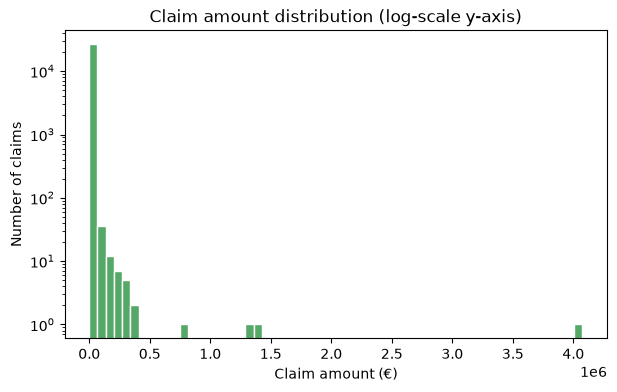

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sev["ClaimAmount"], bins=60, color="#55A868", edgecolor="white")
ax.set_xlabel("Claim amount (\u20ac)")
ax.set_ylabel("Number of claims")
ax.set_yscale("log")
ax.set_title("Claim amount distribution (log-scale y-axis)")
fig.savefig(FIGURES_DIR / "severity_distribution.png", dpi=150)
plt.show()

Even with a log-scale y-axis to make rare large claims visible at all, almost every claim is compressed into the leftmost few bins — the x-axis has to span from €1 to over €4 million to fit the single largest claim, which crushes the view of the far more common €500–€2,000 claims. This is itself informative: no single linear x-axis can show both "what most claims look like" and "how extreme the tail is" at once, which is part of why claim severity is usually modelled with a Gamma or lognormal distribution (log link) rather than a plain Normal/OLS model.

### Large-loss concentration

How much of the total claim bill comes from just the largest few claims?

In [29]:
conc_table = concentration_table(sev["ClaimAmount"], thresholds=[0.01, 0.05, 0.10, 0.25, 0.50])
conc_table

,top_pct,n_claims,share_of_total_value
0,0.01,265,0.380140
1,0.05,1323,0.520931
2,0.10,2645,0.599261
3,0.25,6611,0.716988
4,0.50,13222,0.848952


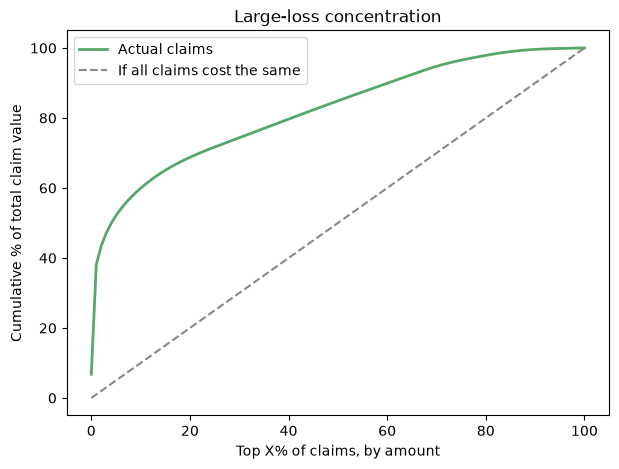

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))
curve = concentration_curve(sev["ClaimAmount"])
ax.plot(curve["pct_claims"] * 100, curve["pct_value"] * 100, color="#55A868", linewidth=2, label="Actual claims")
ax.plot([0, 100], [0, 100], linestyle="--", color="#888888", label="If all claims cost the same")
ax.set_xlabel("Top X% of claims, by amount")
ax.set_ylabel("Cumulative % of total claim value")
ax.set_title("Large-loss concentration")
ax.legend()
fig.savefig(FIGURES_DIR / "severity_concentration_curve.png", dpi=150)
plt.show()

**The top 1% of claims (265 claims out of 26,444) account for 38.0% of all claim value.** The top 5% account for 52.1%, and the top 10% for 59.9% — meaning the *most expensive tenth* of claims costs almost as much as the other nine-tenths combined. At the other end, the cheapest half of all claims contributes only 15.1% of total value.

This is the concrete version of the plan's "large-loss sensitivity" concern (`reports/cleaning_policy.md`, anomaly 4): a severity model's accuracy on the portfolio's total cost will be dominated by how well it handles a few hundred large claims, not by how well it fits the thousands of ordinary ~€1,000–€1,200 claims. Phase 6 will need to check performance with and without the largest claims, exactly because of this concentration.

## 9. Severity by rating factor — and why fewer factors are shown here than for frequency

Frequency in Step 4 was computed over 678,013 policies (hundreds of thousands of policy-years per segment). Severity only has 26,444 claims *total* — conditioning that further by segment leaves some groups with only a few hundred, or even fewer than 200, observations. A single very large claim can then swing a segment's **mean** severity dramatically, while barely moving its **median**. Rather than repeat all nine frequency factors here, three are shown below specifically because they illustrate this problem clearly, alongside the actual claim counts backing each estimate.

In [31]:
sev_joined = sev.merge(
    freq[["IDpol", "DrivAgeBand", "BonusMalusBand", "Area"]], on="IDpol", how="left"
)

drivage_severity = sev_joined.groupby("DrivAgeBand", observed=True)["ClaimAmount"].agg(
    count="count", mean="mean", median="median"
).reset_index()
drivage_severity

,DrivAgeBand,count,mean,median
0,18-22,1271,7980.663564,1172.00
1,23-29,2985,2078.578771,1128.12
2,30-39,5725,1978.028756,1128.12
3,40-49,6566,1872.062909,1172.00
4,50-59,5623,1864.321513,1172.00
5,60-69,2470,1849.267559,1172.00
6,70+,1804,2713.018320,1172.00


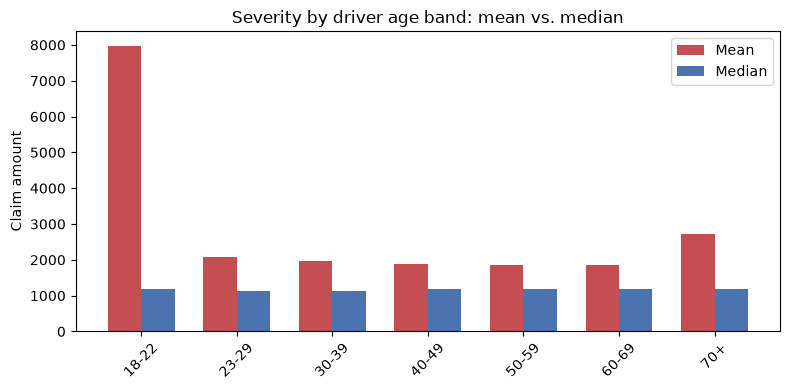

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_mean_vs_median(drivage_severity, "DrivAgeBand", ax=ax, title="Severity by driver age band: mean vs. median")
fig.savefig(FIGURES_DIR / "severity_by_drivage.png", dpi=150)
plt.show()

The 18-22 band shows a **mean** severity of €7,981 — roughly 3-4x every other age band (all of which sit between €1,849 and €2,713). But its **median** is €1,172, identical to every other band. With only 1,271 claims in this band, one or two very large claims are enough to pull the mean far above what a "typical" claim in that band actually costs. This is the opposite conclusion from Step 4's frequency analysis: young drivers genuinely file claims *more often* (well-supported, 16,544 policies), but there is no solid evidence here that their claims are *individually more expensive* — the median says they are not.

In [33]:
bonusmalus_severity = sev_joined.groupby("BonusMalusBand", observed=True)["ClaimAmount"].agg(
    count="count", mean="mean", median="median"
).reset_index()
bonusmalus_severity

,BonusMalusBand,count,mean,median
0,50 (best),11592,1922.221706,1172.00
1,51-59,3034,1993.053546,1128.12
2,60-79,5750,2037.571306,1172.00
3,80-99,3492,2038.054086,1172.00
4,100-129,2415,5053.345901,1172.00
5,130+,161,3373.588758,1172.00


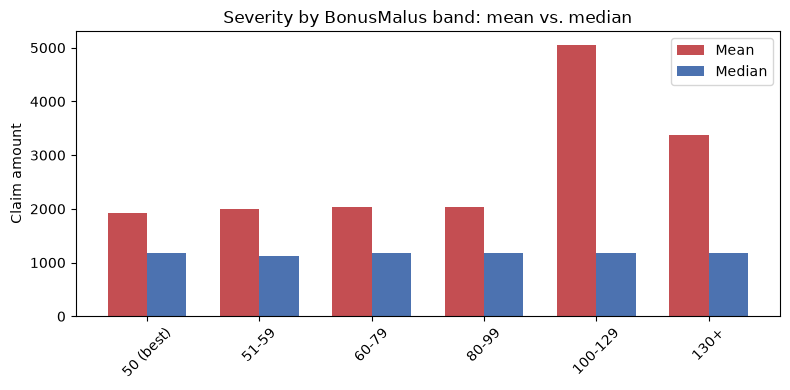

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_mean_vs_median(bonusmalus_severity, "BonusMalusBand", ax=ax, title="Severity by BonusMalus band: mean vs. median")
fig.savefig(FIGURES_DIR / "severity_by_bonusmalus.png", dpi=150)
plt.show()

Same pattern: the `100-129` band's mean jumps to €5,053 (versus ~€1,900-2,040 elsewhere), while its median stays at the same €1,172 as every other band. `BonusMalus` was the *strongest* frequency signal in Step 4 (a real, monotonic, well-supported relationship) — but for severity, the apparent relationship looks driven by a small number of large claims within a moderately sized group (2,415 claims), not a genuine "higher BonusMalus means costlier claims" effect.

In [35]:
area_severity = sev_joined.groupby("Area", observed=True)["ClaimAmount"].agg(
    count="count", mean="mean", median="median"
).reset_index()
area_severity

,Area,count,mean,median
0,A,3364,2300.722554,1172.0
1,B,2633,3370.292260,1172.0
2,C,7093,2060.069425,1172.0
3,D,6458,2243.186925,1172.0
4,E,6122,2126.335560,1172.0
5,F,774,1524.039302,1172.0


`Area` tells the same story again: means range from €1,524 (F) to €3,370 (B) with no clear order matching Area's A→F frequency gradient from Step 4, while medians are flat at €1,172 across every area. Area predicts *how often* a claim happens far more convincingly than *how expensive* it is.

## 10. Summary of Step 5 findings

- Claim severity is extremely right-skewed (skewness ~110); the mean (€2,265) is nearly 2x   the median (€1,172).
- **Large-loss concentration is severe**: the top 1% of claims hold 38.0% of total claim   value; the top 10% hold 59.9%. A severity model's accuracy on total portfolio cost hinges   on a few hundred large claims, not the thousands of ordinary ones.
- **For every rating factor examined (DrivAge, BonusMalus, Area), the median severity is   essentially flat (~€1,172) while the mean varies by 3-4x.** That gap is the signature of a   small number of large claims distorting a segment's average, not a real relationship   between that factor and how expensive a claim is.
- This is a materially different picture from Step 4's frequency findings, where BonusMalus   and DrivAge showed strong, well-supported relationships. **Frequency depends on the   policy's rating factors far more clearly than severity does**, on this univariate evidence   — consistent with the plan's expectation that severity is "intrinsically difficult to   predict from limited policy variables."

For Phase 6, this means: don't expect a severity GLM to explain much variance from rating factors alone, and be explicit that any segment-level mean severity used for pricing should be checked against its median and its claim count — not trusted at face value the way a well-powered frequency estimate can be.